# Notebook 1 - ERA5 Hourly Reanalysis Data

For our project we have vaguely planned to use ERA5 reanalysis data to investigate potential flooding events in Alabama. I don't currently have access to the paleo flood data but I can get a start exploring ERA5 reanalysis data. So this notebook will be a very general overview of some of the ERA5 variables

```{image} ../thumbnails/ECMWF_logo.png
:alt: ECMWF logo
:width: 200px
```

---

## Overview
We will briefly explore one of the variables in ECMWF hourly reanalysis dataset

1. Total Precipitation Variable

## Prerequisites

| Concepts | Importance | Notes |
| --- | --- | --- |
| [Intro to Cartopy](https://foundations.projectpythia.org/core/cartopy/cartopy) | Necessary | |
| [Understanding of NetCDF](https://foundations.projectpythia.org/core/data-formats/netcdf-cf) | Necessary | |
| [XArray](https://foundations.projectpythia.org/core/xarray/) | Necessary | |
| [Pandas](https://foundations.projectpythia.org/core/pandas/) | Necessary | |
| [Datetime](https://foundations.projectpythia.org/core/datetime/) | Necessary | |
| [Matplotlib](https://foundations.projectpythia.org/core/matplotlib/) | Necessary | |

- **Time to learn**: ~ 15 minutes

---

## Imports
Begin your body of content with another `---` divider before continuing into this section, then remove this body text and populate the following code cell with all necessary Python imports **up-front**:

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
from datetime import datetime as dt
import numpy as np
from cartopy import crs as ccrs
from cartopy import feature as cfeature
from metpy.plots import USCOUNTIES

## Total Precipitation Variable

One of the major parts of our project is to see if the coarse ERA5 can resolve high impact precipitation events (at an unknown scale), in order to do this we will need to use data on total precipitation. Lets go ahead and load that data in. 

In [2]:
ds = xr.open_dataset('https://data.earthdatahub.destine.eu/era5/reanalysis-era5-single-levels-v0.zarr', 
                         chunks = {}, storage_options = {"client_kwargs": {"trust_env": True}}, consolidated = True, engine = "zarr")
ds

<xarray.Dataset> Size: 400TB
Dimensions:     (valid_time: 751680, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2025-09-30T23:...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
    surface     float64 8B ...
Data variables: (12/128)
    alnid       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    alnip       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    aluvd       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    aluvp       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    anor        (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    asn         (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    ...          ...
    viiwn       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    vilwd       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    vilwe       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    vilwn       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    z           (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    zust        (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2025-02-13T19:10 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

Okay perfect, lets pick a time range, lat lon range, and isolate the total precipitation variable, tp.

In [3]:
year = 1952
month = 9
day = 3
hour = 12
start_dateTime = dt(year, month, day, hour)
start_timeString = start_dateTime.strftime("%Y-%m-%d %H%M UTC")

year = 1953
month = 9
day = 3
hour = 12
end_dateTime = dt(year, month, day, hour)
end_timeString = end_dateTime.strftime("%Y-%m-%d %H%M UTC")

latRange = [ds['latitude'].sel(latitude = 30.21, method = 'nearest'), ds['latitude'].sel(latitude = 35.12, method = 'nearest')]
lonRange = [ds['longitude'].sel(longitude = -88.34 + 360, method = 'nearest'), ds['longitude'].sel(longitude = -84.89 + 360, method = 'nearest')]

tp = ds['tp'].sel(valid_time = slice(start_dateTime, end_dateTime), latitude = latRange, longitude = lonRange)

In [4]:
tp

<xarray.DataArray 'tp' (valid_time: 8761, latitude: 2, longitude: 2)> Size: 140kB
dask.array<getitem, shape=(8761, 2, 2), dtype=float32, chunksize=(4320, 2, 2), chunktype=numpy.ndarray>
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 70kB 1952-09-03T12:00:00 ... 1953...
  * latitude    (latitude) float64 16B 30.25 35.0
  * longitude   (longitude) float64 16B 271.8 275.0
    number      int64 8B ...
    surface     float64 8B ...
Attributes: (12/31)
    GRIB_NV:                                  0
    GRIB_Nx:                                  1440
    GRIB_Ny:                                  721
    GRIB_cfName:                              unknown
    GRIB_cfVarName:                           tp
    GRIB_dataType:                            fc
    ...                                       ...
    GRIB_typeOfLevel:                         surface
    GRIB_units:                               m
    GRIB_uvRelativeToGrid:                    0
    long_name:                                Total precipitation
    standard_name:                            unknown
    units:                                    m

Okay perfect, now we have a year of hourly precipitation data over the entire state of Alabama. Now lets grab the data for one grid point and then plot a time series to identify potential events that may be of note.

In [5]:
# The lat lon of the lake we have samples from is roughly 33.007, -87.6618
tp_point = tp.sel(latitude = 33.007, longitude = -87.6618 + 360, method = 'nearest')
tp_point

<xarray.DataArray 'tp' (valid_time: 8761)> Size: 35kB
dask.array<getitem, shape=(8761,), dtype=float32, chunksize=(4320,), chunktype=numpy.ndarray>
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 70kB 1952-09-03T12:00:00 ... 1953...
    latitude    float64 8B 35.0
    longitude   float64 8B 271.8
    number      int64 8B ...
    surface     float64 8B ...
Attributes: (12/31)
    GRIB_NV:                                  0
    GRIB_Nx:                                  1440
    GRIB_Ny:                                  721
    GRIB_cfName:                              unknown
    GRIB_cfVarName:                           tp
    GRIB_dataType:                            fc
    ...                                       ...
    GRIB_typeOfLevel:                         surface
    GRIB_units:                               m
    GRIB_uvRelativeToGrid:                    0
    long_name:                                Total precipitation
    standard_name:                            unknown
    units:                                    m

Text(0, 0.5, 'Hourly Precip (m)')

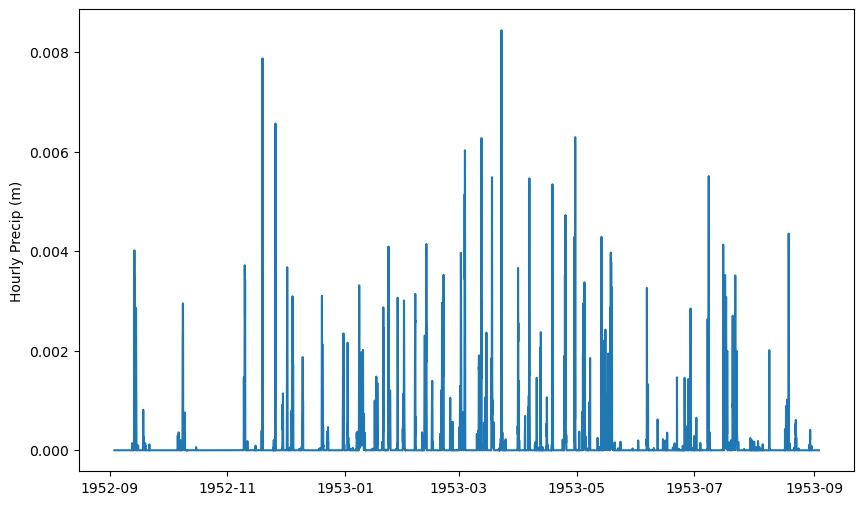

In [6]:
fig = plt.figure(figsize = (10, 6))
plt.plot(tp_point['valid_time'], tp_point)
plt.ylabel("Hourly Precip (m)")


It's important to note that these are hourly rainfall totals, so not accumulated over several days. Looks like there was a significant event in March of 1953, lets scope in the plot further to get more information

Text(0, 0.5, 'Hourly Precip (m)')

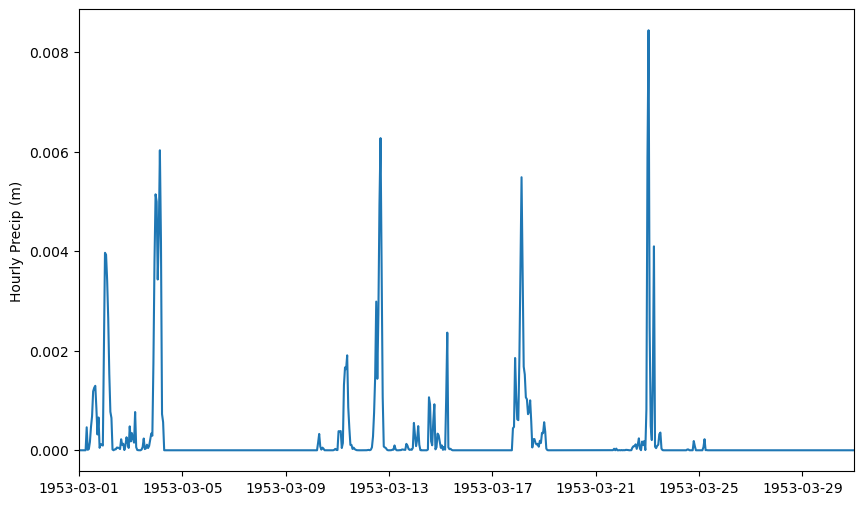

In [7]:
year = 1953
month = 3
day = 1
hour = 00
start_march = dt(year, month, day, hour)

year = 1953
month = 3
day = 31
hour = 00
end_march = dt(year, month, day, hour)


fig = plt.figure(figsize = (10, 6))
plt.plot(tp_point['valid_time'], tp_point)
plt.xlim(start_march, end_march)
plt.ylabel("Hourly Precip (m)")

Perfect, looks like there may have been a significant rain event in mid march, lets plot it on an interactive map in the next section

---

## Summary
Now we have explored the process of identifying an event, we should be able to do similar analysis with all of the variables contained in the dataset.

### What's next?
In the next notebook we will explore plotting an interactive map of one of the precipitation events we have identified. 

## Resources and references

Data from Earth Data Hub located at https://earthdatahub.destine.eu/collections/era5/datasets/reanalysis-era5-single-levels
 